## 1. DATA LOADING
Download data and do a first quick review


### 1.1 Import libraries

In [68]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 




### 1.2 Load raw data

In [69]:
# download csv file with data base
df = pd.read_csv('C:/MyFiles/Study/Charity_Grant_Analysis/data/360giving_grants.csv')

### 1.3 First look

In [70]:

#size of the data frame
print(f' We have rows and columns {df.shape}')


 We have rows and columns (449414, 14)


In [71]:
#display first 5 rows
df.head()

,Title,Description,Amount Awarded,Award Date,Recipient Org:Name,Funding Org:Name,Funding Org: Org Type (additional data),Recipient Region (additional data),Best Available Region (additional data),Type of Recipient,Grant Programme:Title,Recipient Org: Org Type (additional data),License,Note See http://grantnav.threesixtygiving.org/datasets/ for further license information.
0,Grant to Youth Learning Network Ltd,Our Routes2Success (R2S) programme will be wor...,3011.14,2024-10-19,Youth Learning Network Ltd,Co-operative Group,Grantmaking Organisation,London,London,Organisation,Co-op Local Community Fund,Registered Charity,https://creativecommons.org/licenses/by-sa/4.0/,NaN
1,A grant to Rights & Security International,"A restricted grant of £25,000 towards UK work ...",25000.00,2025-03-17,Rights & Security International,A B Charitable Trust,Grantmaking Organisation,London,London,Organisation,The Human Rights Framework,Registered Charity,https://creativecommons.org/licenses/by/4.0/,NaN
2,A grant to Hillingdon Law Centre,"An unrestricted grant of £25,000 (This grant i...",25000.00,2025-03-17,Hillingdon Law Centre,A B Charitable Trust,Grantmaking Organisation,London,London,Organisation,Access to Justice,Registered Charity,https://creativecommons.org/licenses/by/4.0/,NaN
3,A grant to ECPAT UK,"An unrestricted grant of £25,000 (This grant i...",25000.00,2025-03-17,ECPAT UK,A B Charitable Trust,Grantmaking Organisation,London,London,Organisation,Migrants and Refugees,Registered Charity,https://creativecommons.org/licenses/by/4.0/,NaN
4,A grant to Paddington Law Centre,"An unrestricted grant of £20,000 (This grant i...",20000.00,2025-03-17,Paddington Law Centre,A B Charitable Trust,Grantmaking Organisation,London,London,Organisation,Access to Justice,Registered Charity,https://creativecommons.org/licenses/by/4.0/,NaN


In [72]:
# display data types 
print(f'Data types in the dataframe:\n {df.dtypes}')

Data types in the dataframe:
 Title                                                                                        object
Description                                                                                  object
Amount Awarded                                                                              float64
Award Date                                                                                   object
Recipient Org:Name                                                                           object
Funding Org:Name                                                                             object
Funding Org: Org Type (additional data)                                                      object
Recipient Region (additional data)                                                           object
Best Available Region (additional data)                                                      object
Type of Recipient                                                     

In [73]:
# Do we have missing values?
df.isna().sum()



Title                                                                                            8
Description                                                                                      4
Amount Awarded                                                                                   0
Award Date                                                                                       0
Recipient Org:Name                                                                          138106
Funding Org:Name                                                                                 0
Funding Org: Org Type (additional data)                                                          0
Recipient Region (additional data)                                                               0
Best Available Region (additional data)                                                          0
Type of Recipient                                                                                0
Grant Prog

In [74]:
# quick analysis of numbers columns
df['Amount Awarded'].describe()

count    4.494140e+05
mean     1.750841e+05
std      7.051984e+06
min     -4.586625e+07
25%      4.553800e+02
50%      5.000000e+03
75%      2.496900e+04
max      2.351584e+09
Name: Amount Awarded, dtype: float64

### Results

- The dataset contains 449,414 rows and 14 columns.
- Most columns are of type `object` (including the date column).
- There are no missing values in 12 columns. Only 8 values are missing in `Title` and 4 in `Description`, which is not critical.
- There are 138,106 missing values in `Recipient Org: Name`. We also have missing values in `Grant Programme: Title` (34,441) and `Recipient Org: Org Type (additional data)` (277,395).
- This is likely due to individual recipients; I will inspect these columns after removing individuals.
- From a quick analysis, the mean of `Amount Awarded` is 175,084.08. Negative values represent returned funds.

Now we need to create a cleaned dataset that will help answer our questions.

## 2. DATA CLEANING
To answer our questions we will perform the following steps:

1. Remove records with negative `Amount Awarded`.
2. Filter out individual recipients — focus only on grants to organisations.
3. Drop unnecessary columns (for example, `Best Available Region` and `License`).
4. Convert column data types where needed (e.g., parse dates).

### 2.1 Remove negative values

In [75]:
# Remove all data with minus
df_new = df[df['Amount Awarded']>0]
df_new.head(3)

,Title,Description,Amount Awarded,Award Date,Recipient Org:Name,Funding Org:Name,Funding Org: Org Type (additional data),Recipient Region (additional data),Best Available Region (additional data),Type of Recipient,Grant Programme:Title,Recipient Org: Org Type (additional data),License,Note See http://grantnav.threesixtygiving.org/datasets/ for further license information.
0,Grant to Youth Learning Network Ltd,Our Routes2Success (R2S) programme will be wor...,3011.14,2024-10-19,Youth Learning Network Ltd,Co-operative Group,Grantmaking Organisation,London,London,Organisation,Co-op Local Community Fund,Registered Charity,https://creativecommons.org/licenses/by-sa/4.0/,NaN
1,A grant to Rights & Security International,"A restricted grant of £25,000 towards UK work ...",25000.00,2025-03-17,Rights & Security International,A B Charitable Trust,Grantmaking Organisation,London,London,Organisation,The Human Rights Framework,Registered Charity,https://creativecommons.org/licenses/by/4.0/,NaN
2,A grant to Hillingdon Law Centre,"An unrestricted grant of £25,000 (This grant i...",25000.00,2025-03-17,Hillingdon Law Centre,A B Charitable Trust,Grantmaking Organisation,London,London,Organisation,Access to Justice,Registered Charity,https://creativecommons.org/licenses/by/4.0/,NaN


In [76]:
df_new.shape

(444998, 14)

### 2.2 Filter by recipient type

In [77]:
# Filter our database and remove individuals. We are focused only in grants for organisations
# Let's see what we have in a column ['Type of Recipient]
df_new_1 = df_new['Type of Recipient'].value_counts()
display(df_new_1)


Type of Recipient
Organisation    306893
Individual      138105
Name: count, dtype: int64

In [78]:
# let's leave only Organisation type because this is our focus
df_charity = df_new[df_new['Type of Recipient'] == 'Organisation']

In [79]:
# now let's delete extra columns
df_charity = df_charity.drop(columns=['Best Available Region (additional data)', 'License', 'Note See http://grantnav.threesixtygiving.org/datasets/ for further license information.'], errors='ignore')

In [80]:
df_charity['Type of Recipient'].value_counts()

Type of Recipient
Organisation    306893
Name: count, dtype: int64

In [81]:
# double check
df_charity.columns

Index(['Title', 'Description', 'Amount Awarded', 'Award Date',
       'Recipient Org:Name', 'Funding Org:Name',
       'Funding Org: Org Type (additional data)',
       'Recipient Region (additional data)', 'Type of Recipient',
       'Grant Programme:Title', 'Recipient Org: Org Type (additional data)'],
      dtype='object')

In [82]:
#change data column type 
df_charity['Award Date'] = pd.to_datetime(df_charity['Award Date'])

### 2.3 Verify clean data

In [83]:
#lets check our new data frame
df_charity.shape 


(306893, 11)

In [84]:
print(f'our data base decreased on {len(df)-len(df_charity)} grants')

our data base decreased on 142521 grants


In [85]:
#check type of columns
df_charity.dtypes

Title                                                object
Description                                          object
Amount Awarded                                      float64
Award Date                                   datetime64[ns]
Recipient Org:Name                                   object
Funding Org:Name                                     object
Funding Org: Org Type (additional data)              object
Recipient Region (additional data)                   object
Type of Recipient                                    object
Grant Programme:Title                                object
Recipient Org: Org Type (additional data)            object
dtype: object

In [86]:
#basic info about Awarded Amount
df_charity['Amount Awarded'].describe()

count    3.068930e+05
mean     2.578290e+05
std      8.530877e+06
min      1.000000e-02
25%      4.479120e+03
50%      1.299306e+04
75%      5.579800e+04
max      2.351584e+09
Name: Amount Awarded, dtype: float64

In [87]:
#check missing values now
df_charity.isna().sum()

Title                                             8
Description                                       4
Amount Awarded                                    0
Award Date                                        0
Recipient Org:Name                                1
Funding Org:Name                                  0
Funding Org: Org Type (additional data)           0
Recipient Region (additional data)                0
Type of Recipient                                 0
Grant Programme:Title                         31721
Recipient Org: Org Type (additional data)    136192
dtype: int64

In [88]:
#let's dive dipper
df_charity['Recipient Org:Name'].value_counts().sort_values(ascending=False)

Recipient Org:Name
University College London                       1450
Imperial College London                         1200
University of Oxford                             987
Individual Recipient                             928
University of Cambridge                          782
                                                ... 
Brass                                              1
ACES Bridlington Club and Friends by the Sea       1
Weighton Wildlife Group                            1
Rotary Club of Malton and Norton                   1
Decadent Drawing CIC                               1
Name: count, Length: 134156, dtype: int64

### Results

- We reduced the dataset; `df_charity` is our working dataset now.
- The dataset decreased by  142521 grants.
- The mean `Amount Awarded` remains similar but is far above most grant amounts, indicating a skewed distribution.
-We still have 138106 missing values in 'Recipient Org:Name'. This is 31% of data. We can work with this because this is not the main focus for us.
- Our dataset has only  organisations grants and this is  306893 (68.97 % from all cases)

## 3. ANALYSIS

 

### 3.1 Question 1: Grant amounts

We have a dataframe df_charity. I need to:

1) Keep only organisations related to charities in the column Recipient Org: Org Type (additional data)
2) Filter grants by amount: from £1,000 to £100,000
3) Keep only grants that go to real charity projects — exclude NHS, universities, councils. We create a blacklist of keywords in descriptions.

In [ ]:
#1: Filter by organisation type
keep_types = [
    'Registered Charity',
    'Community Interest Company',
    'Charitable Incorporated Organisation',
    'Community Amateur Sports Club'
]


df_charity_types = df_charity[df_charity['Recipient Org: Org Type (additional data)'].isin(keep_types)].copy()


In [130]:
# Check results: How many rows were in df_charity? How many rows in df_charity_types? What types remained?

print(f'I had {len(df_charity)} grants in total')
print(f'After filtering I have {len(df_charity_types)} grants, this is {len(df_charity)-len(df_charity_types)} less, so I have {round(len(df_charity_types)/len(df_charity)*100,0)}% of the original dataset')

I had 306893 grants in total
After filtering I have 137443 grants, this is 169450 less, so I have 45.0% of the original dataset


In [ ]:
# Check remaining organisation types
df_charity_types.value_counts('Recipient Org: Org Type (additional data)')

Recipient Org: Org Type (additional data)
Registered Charity                      121656
Community Interest Company               15290
Community Amateur Sports Club              362
Charitable Incorporated Organisation       135
Name: count, dtype: int64

In [ ]:
# Filter by grant amount: £1K - £100K

df_charity_size = df_charity_types[
    (df_charity_types['Amount Awarded']>=1000) & 
    (df_charity_types['Amount Awarded']<=100_000)
].copy()

In [131]:
# Check results  

print(
    f'I had {len(df_charity_types)} grants in correct categories. '
    f'After filtering by amount: {len(df_charity_size)} grants remained, '
    f'this is {round(len(df_charity_size)/len(df_charity_types)*100, 0)}% '
    f'of the dataset. '
    f'Compared to the original dataset, we have '
    f'{round(len(df_charity_size)/len(df_charity)*100, 0)}% left.'
)

I had 137443 grants in correct categories. After filtering by amount: 115287 grants remained, this is 84.0% of the dataset. Compared to the original dataset, we have 38.0% left.


In [94]:
# min/max/median 
df_charity_size['Amount Awarded'].describe()

count    115287.000000
mean      16481.708604
std       19993.599473
min        1000.000000
25%        4426.000000
50%        9990.000000
75%       20000.000000
max      100000.000000
Name: Amount Awarded, dtype: float64

In [132]:
# Filter 3: Exclude universities, councils, NHS, research centres

# 1. Create exclusion list

exclude_keywords = [
    'University', 
    'College', 
    'Council', 
    'NHS', 
    'Department', 
    'Laboratory', 
    'INST',
    'Research Centre',
    'Medical Centre',
    'JOHN INNES CENTRE',
    'UK CENTRE FOR ECOLOGY & HYDROLOGY',
    'National Oceanography Centre'
]

# 2. Create final clean dataset for analysis

df_community_focus = df_charity_size[
    ~df_charity_size['Recipient Org:Name'].str.contains('|'.join(exclude_keywords), case=False, na=False)
    ].copy()

In [133]:
print("FILTERING RESULTS:")
print(f"Before exclusions: {len(df_charity_size):,} grants")
print(f"After exclusions: {len(df_community_focus):,} grants")
print(f"Removed: {len(df_charity_size) - len(df_community_focus):,} grants")
print(f"Remaining: {round(len(df_community_focus)/len(df_charity_size)*100, 1)}%")

FILTERING RESULTS:
Before exclusions: 115,287 grants
After exclusions: 112,516 grants
Removed: 2,771 grants
Remaining: 97.6%


In [134]:
print("\nTOP 20 RECIPIENTS (by number of grants):")
print(df_community_focus['Recipient Org:Name'].value_counts().head(20))


TOP 20 RECIPIENTS (by number of grants):
Recipient Org:Name
CALICO HOMES LIMITED                   91
Cruse Bereavement Support              84
CoLab Exeter                           45
Exeter Community Initiatives           41
WALSALL HOUSING GROUP LIMITED          38
Spring Community Hub                   38
British Red Cross                      36
Mustard Tree                           33
Beyond Limits                          32
FWAG SOUTH WEST                        32
Jigsaw Homes Tameside                  31
THAMES21 LIMITED                       31
Tyne Rivers Trust                      30
Bright Futures NE                      30
Women Asylum Seekers Together          30
Watten Helps Out                       29
Building Self-belief CIO               28
Sabhal Mòr Ostaig                      28
United African Association             28
North Tyneside Disability Forum Ltd    28
Name: count, dtype: int64


In [135]:
print("\nAMOUNT STATISTICS (df_community_focus):")
print(df_community_focus['Amount Awarded'].describe())


AMOUNT STATISTICS (df_community_focus):
count    112516.000000
mean      16327.468104
std       19853.259579
min        1000.000000
25%        4361.000000
50%        9980.000000
75%       20000.000000
max      100000.000000
Name: Amount Awarded, dtype: float64


In [136]:
# Calculate median and mode
print(df_community_focus['Amount Awarded'].median())
print(df_community_focus['Amount Awarded'].mode())

9980.0
0    10000.0
Name: Amount Awarded, dtype: float64


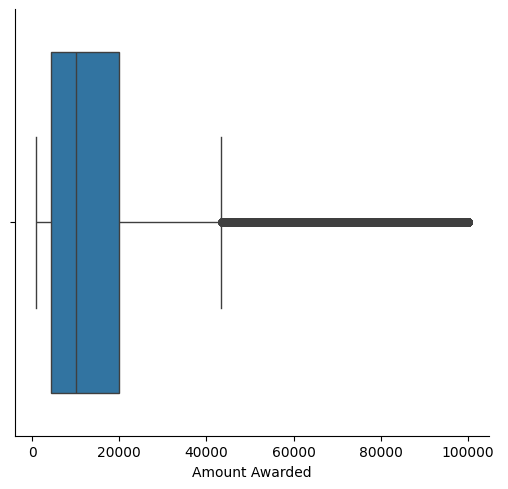

In [137]:
# Visualise grant amount distribution

sns.catplot(x='Amount Awarded', data=df_community_focus, kind='box')
plt.show()

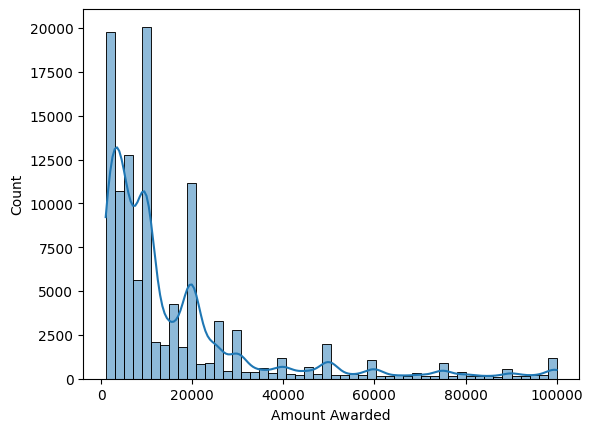

In [101]:
sns.histplot(data=df_community_focus, bins=50, x="Amount Awarded",kde=True)
plt.show()
 

In [138]:
# Create summary table of all filtering stages

summary = pd.DataFrame({
    'Stage': [0, 1, 2, 3],
    'Dataset': ['df', 'df_charity_types', 'df_charity_size', 'df_community_focus'],
    'Rows': [len(df), len(df_charity_types), len(df_charity_size), len(df_community_focus)],
    'Deleted rows': [0, len(df)-len(df_charity_types), len(df_charity_types)-len(df_charity_size), len(df_charity_size)-len(df_community_focus)],
    'What we deleted?': ['nothing', 'individuals + non-charity org types', 'grants less than 1K & more than 100K', 'universities, councils, NHS, research centres']
})
summary

,Stage,Dataset,Rows,Deleted rows,What we deleted?
0,0,df,449414,0,nothing
1,1,df_charity_types,137443,311971,individuals + non-charity org types
2,2,df_charity_size,115287,22156,grants less than 1K & more than 100K
3,3,df_community_focus,112516,2771,"universities, councils, NHS, research centres"


In [139]:
print(f'We have {round(len(df_community_focus)/len(df)*100,1)}% of the original dataset remaining')

We have 25.0% of the original dataset remaining


## Result

**Question 1: What grant amount can we expect?**

Based on analysis of 112,516 grants for community charities in the UK (2022-2024):

**Typical grant: £10,000**

The median is £9,980, the mode is exactly £10,000. This means half of all grants are below this amount, and £10K is the most frequently awarded sum. For a small charity in Cornwall this is a realistic target for first applications.

**Expected range:**

25% of grants: up to £4,361
50% of grants: up to £9,980
75% of grants: up to £20,000

**Practical recommendation:** Start with applications for £5,000-10,000 — this is the "comfort zone" for most funders. After a successful track record you can move to applications for £15,000-20,000.

### 3.2 Question 2: Focus areas

In [140]:
# View our clean dataset
df_community_focus.head(20)

,Title,Description,Amount Awarded,Award Date,Recipient Org:Name,Funding Org:Name,Funding Org: Org Type (additional data),Recipient Region (additional data),Type of Recipient,Grant Programme:Title,Recipient Org: Org Type (additional data)
0,Grant to Youth Learning Network Ltd,Our Routes2Success (R2S) programme will be wor...,3011.14,2024-10-19,Youth Learning Network Ltd,Co-operative Group,Grantmaking Organisation,London,Organisation,Co-op Local Community Fund,Registered Charity
1,A grant to Rights & Security International,"A restricted grant of £25,000 towards UK work ...",25000.00,2025-03-17,Rights & Security International,A B Charitable Trust,Grantmaking Organisation,London,Organisation,The Human Rights Framework,Registered Charity
2,A grant to Hillingdon Law Centre,"An unrestricted grant of £25,000 (This grant i...",25000.00,2025-03-17,Hillingdon Law Centre,A B Charitable Trust,Grantmaking Organisation,London,Organisation,Access to Justice,Registered Charity
3,A grant to ECPAT UK,"An unrestricted grant of £25,000 (This grant i...",25000.00,2025-03-17,ECPAT UK,A B Charitable Trust,Grantmaking Organisation,London,Organisation,Migrants and Refugees,Registered Charity
4,A grant to Paddington Law Centre,"An unrestricted grant of £20,000 (This grant i...",20000.00,2025-03-17,Paddington Law Centre,A B Charitable Trust,Grantmaking Organisation,London,Organisation,Access to Justice,Registered Charity
5,A grant to Maternity Action,"An unrestricted grant of £30,000 (This grant i...",30000.00,2025-03-17,Maternity Action,A B Charitable Trust,Grantmaking Organisation,London,Organisation,Access to Justice,Registered Charity
6,A grant to Doctors of the World UK,"An unrestricted grant of £30,000 (This grant i...",30000.00,2025-03-17,Doctors of the World UK,A B Charitable Trust,Grantmaking Organisation,London,Organisation,Migrants and Refugees,Registered Charity
7,A grant to Asylum Link Merseyside (ALM),"An unrestricted grant of £25,000 (This grant i...",25000.00,2025-03-17,Asylum Link Merseyside (ALM),A B Charitable Trust,Grantmaking Organisation,North West,Organisation,Migrants and Refugees,Registered Charity
8,A grant to Belong Nottingham,"An unrestricted grant of £25,000 (This grant i...",25000.00,2025-03-17,Belong Nottingham,A B Charitable Trust,Grantmaking Organisation,East Midlands,Organisation,Migrants and Refugees,Registered Charity
9,A grant to Hope at Home,"An unrestricted grant of £20,000 (This grant i...",20000.00,2025-03-17,Hope at Home,A B Charitable Trust,Grantmaking Organisation,West Midlands,Organisation,Migrants and Refugees,Registered Charity


In [141]:
# Group by grant programme title
df_community_focus['Grant Programme:Title'].value_counts()

Grant Programme:Title
National Lottery Awards for All England     14069
Co-op Local Community Fund                   6442
Community Grant                              2960
Small Grants                                 2382
Welfare                                      1487
                                            ...  
Heritage and Arts - Mercers’ Arts Awards        1
Other Programmes                                1
Young People and Education - Other              1
Arts                                            1
Arts Culture and Heritage                       1
Name: count, Length: 2590, dtype: int64

In [106]:
df_community_focus['Description'].sample(30)

330364    £4,996 single grant towards a salary and costs...
62790     to support service users' attendance to a comm...
36562     We would like to be able to offer our children...
46907     towards one year's running costs of the organi...
16756                        Brain Tumour Support Services.
22313     Purchase and supply Automatic External Defibri...
79707            towards core costs over the next 12 months
363363    To support the modernisation and improvement o...
179381                   Women and Cancer - An Unique Story
436691                                       Cost of living
38794     We would like to organise events to give away ...
237709    The main priority for Countryside Stewardship ...
27383     Activities to raise awareness of cancer amongs...
84172     To install free public Wi-Fi for central Dufft...
70129     The funding will allow communities to come tog...
22728     Core costs for Advancement of Health/Saving Lives
203209        Grant to Breaking Barriers

In [142]:
# Check keywords in descriptions to understand what to include
df_community_focus['Description'].str.contains('community', case=False, na=False).sum()

np.int64(21856)

In [108]:
df_community_focus['Description'].str.contains('poverty', case=False, na=False).sum()

np.int64(1586)

In [109]:
df_community_focus['Description'].str.contains('children', case=False, na=False).sum()

np.int64(10568)

In [110]:
df_community_focus['Description'].str.contains('mental health', case=False, na=False).sum()

np.int64(6569)

In [111]:
df_community_focus['Description'].str.contains('refugee', case=False, na=False).sum()

np.int64(1853)

In [112]:
df_community_focus['Description'].str.contains('elderly', case=False, na=False).sum()

np.int64(641)

In [113]:
df_community_focus['Description'].str.contains('family', case=False, na=False).sum()

np.int64(2395)

In [114]:
df_community_focus['Description'].str.contains('homeless', case=False, na=False).sum()

np.int64(1469)

In [115]:
df_community_focus['Description'].str.contains('disability', case=False, na=False).sum()

np.int64(849)

In [116]:
df_community_focus['Description'].str.contains('loneliness', case=False, na=False).sum()

np.int64(1483)

In [117]:
df_community_focus['Description'].str.contains('older people', case=False, na=False).sum()

np.int64(2131)

In [118]:
df_community_focus['Description'].str.contains('young people', case=False, na=False).sum()

np.int64(11737)

In [119]:
df_community_focus['Description'].str.contains('cost of living', case=False, na=False).sum()

np.int64(3303)

In [120]:
df_community_focus['Description'].str.contains('dementia', case=False, na=False).sum()

np.int64(891)

In [143]:
# Keywords validated on data

youth_words = 'young people|children|child|youth|gym'
health_words = 'mental health|disability|loneliness|wellbeing|counselling|depression|well-being'
poverty_words = 'poverty|cost of living|homeless|food bank|hardship|debt|foodbank'
elderly_words = 'older people|elderly|dementia|aged|pensioner|older|seniors'
refugee_words = 'refugee|asylum|migrant'
family_words = 'family|families|parent|domestic abuse'
charity_words = 'salary|charity|staff|core funding'

# Create flag columns in our dataset
df_community_focus['Is_youth'] = df_community_focus['Description'].str.contains(youth_words, case=False, na=False)
df_community_focus['Is_health'] = df_community_focus['Description'].str.contains(health_words, case=False, na=False)
df_community_focus['Is_poverty'] = df_community_focus['Description'].str.contains(poverty_words, case=False, na=False)
df_community_focus['Is_elderly'] = df_community_focus['Description'].str.contains(elderly_words, case=False, na=False)
df_community_focus['Is_refugee'] = df_community_focus['Description'].str.contains(refugee_words, case=False, na=False)
df_community_focus['Is_family'] = df_community_focus['Description'].str.contains(family_words, case=False, na=False)
df_community_focus['Is_charity'] = df_community_focus['Description'].str.contains(charity_words, case=False, na=False)

# Create list of categories
categories = ['Is_youth', 'Is_health', 'Is_poverty', 'Is_elderly', 'Is_refugee', 'Is_family', 'Is_charity']

# Calculate count and total amount for each category
results = []
for cat in categories:
    # Filter dataset where flag = True
    temp_df = df_community_focus[df_community_focus[cat] == True]
    
    results.append({
        'Category': cat.replace('Is_', ''),  # Remove prefix for cleaner output
        'Grant_Count': temp_df['Amount Awarded'].count(),
        'Total_Amount': temp_df['Amount Awarded'].sum()
    })

# Create summary table
df_themes = pd.DataFrame(results).sort_values('Total_Amount', ascending=False)
display(df_themes)

,Category,Grant_Count,Total_Amount
0,youth,22107,3.444946e+08
1,health,17253,2.695814e+08
6,charity,9443,1.772118e+08
5,family,10339,1.691463e+08
3,elderly,10529,1.595785e+08
2,poverty,8080,1.083144e+08
4,refugee,2684,4.910323e+07


In [144]:
# Сколько грантов НЕ попали ни в одну категорию? Это покажет, насколько полный твой список ключевых слов.
# Гранты без категории = все флаги False

has_category = (df_community_focus['Is_youth'] | 
                df_community_focus['Is_health'] | 
                df_community_focus['Is_poverty'] | 
                df_community_focus['Is_elderly'] | 
                df_community_focus['Is_refugee'] | 
                df_community_focus['Is_family'] |
                df_community_focus['Is_charity'])

print(f"Без категории: {(~has_category).sum()}")
        

Без категории: 56643


In [ ]:
# 10 real examples from Youth category

example = df_community_focus[df_community_focus['Is_youth']][['Title', 'Description', 'Grant Programme:Title']].sample(50)
example

,Title,Description,Grant Programme:Title
79460,Grant to Gympanzees,"As requested by the fund holder, matched donat...",Donor Directed
58258,Next Gen Summit,"My Life My Say (MLMS) is a youth-led, non-part...",Other grants and programmes - Development Fund
445696,UnlimitedPotential,ZamZam Unlimited Possibilities CIC - Children ...,National Lottery Awards for All England
329735,Grant to Dragon Tale Theatre Group,core costs towards creative activities with yo...,NaN
174490,In2 Health & Wellbeing,The funding is for the provision of sport and ...,Small Grants
74396,MCF Large Grant,To support the salary of the specialist disabi...,Large Grant
335818,Community Gardens Project,Engaging local schools that have a high percen...,Julia Rausing Memorial Grants
4505,"Climbing for Mental Health, for Neurodivergent...",This project will deliver 50 Therapeutic Climb...,Small Grants
19422,Main Grants award,The Machan Trust Children's Youth and families...,Youth
44802,Grant to Strathearn JAC,We'd like to continue providing meaningful act...,Co-op Local Community Fund


In [124]:
df_community_focus[df_community_focus['Is_health']][['Title', 'Description']].sample(10)

,Title,Description
325187,BENS CLUB,The funding will be used to provide mental hea...
194528,Each one Teach one Project,The funding will be used to run intergeneratio...
363364,Platinum Jubilee Village Halls Fund,To support the modernisation and improvement o...
39334,Grant to Group 64 Theatre for Young People,We would like to create a series of drama work...
73760,Cindy Smiley,To fund a mentoring programme supporting the e...
435714,The Exchange Community Hub,The funding will be used to cover the staffing...
324387,Ladies' Self-esteem,The funding will be used to support vulnerable...
70882,Community classroom and kitchen refurbishment,The funding will be used to establish communit...
4849,Elite Squad,This project will run for 6 months and will co...
37539,Grant to Smile Group,We have a group in Congleton at the children's...


## Results

**Question 2: Which focus areas attract most grant funding?**

Based on analysis of 112,516 grants for community charities in the UK (2022-2024), classified into 7 focus areas:

**Top focus areas by funding volume:**

**Youth (children and young people)** — clear leader: 22,107 grants totalling £344M. One in five grants in the sector goes to work with children and young people.

**Health (health and wellbeing)** — second place: 17,253 grants, £258M. Includes mental health, disability support, counselling.

**Family** — 10,339 grants, £169M. Parenting support, family programmes, protection from domestic abuse.

**Elderly** — 10,529 grants, £159M. Dementia support, tackling isolation, carer support.

**Poverty** — 8,080 grants, £108M. Food banks, homelessness, cost of living crisis.

**Refugee** — 2,684 grants, £49M. Fewest grants, BUT highest average grant (£18,300 vs £13,400-16,400 in other categories).

**Recommendation for Cornwall community charity:**

If the goal is to maximise chances of getting a grant, focus on Youth or Health — these are the most funded areas with the most opportunities.

If the charity already works with refugees — this is a niche with less competition and larger grants.

### 3.3 Question 3: Funders

Who funds community charities: government or private funders?**  
Where should we direct our application efforts?


In [127]:
df_community_focus['Funding Org:Name'].value_counts()

Funding Org:Name
The National Lottery Community Fund    25132
Co-operative Group                      6449
Garfield Weston Foundation              5189
Sport England                           3781
Community Foundation North East         2175
                                       ...  
Joffe Charitable Trust                     1
Violence Reduction Unit                    1
Department for International Trade         1
Postcode Planet Trust                      1
Skinners' Education Foundation             1
Name: count, Length: 289, dtype: int64

In [145]:
# Look at amounts awarded by funder type

df_community_focus.groupby('Funding Org: Org Type (additional data)').agg(Total_amount=('Amount Awarded', 'sum'), Quntiaty_Count=('Amount Awarded', 'count'), Sum_avarage = ('Amount Awarded', 'mean')).reset_index()

,Funding Org: Org Type (additional data),Total_amount,Quntiaty_Count,Sum_avarage
0,Central Government,1.545537e+08,6061,25499.702920
1,Devolved Government,1.642000e+05,6,27366.666667
2,Grantmaking Organisation,1.165071e+09,74219,15697.749447
3,Local Government,3.158291e+07,1857,17007.490474
4,Lottery Distributor,4.857293e+08,30373,15992.141897


In [129]:
the_biggest_donor = df_community_focus.groupby('Funding Org:Name').agg(Total_amount=('Amount Awarded', 'sum'), Quntiaty_Count=('Amount Awarded', 'count'), Sum_avarage = ('Amount Awarded', 'mean')).reset_index()
the_biggest_donor.sort_values('Total_amount', ascending= False).head(10)

,Funding Org:Name,Total_amount,Quntiaty_Count,Sum_avarage
244,The National Lottery Community Fund,3.862762e+08,25132,15369.896619
76,Garfield Weston Foundation,1.251016e+08,5189,24108.990172
245,The National Lottery Heritage Fund,5.668296e+07,1460,38823.943151
121,Lloyds Bank Foundation for England and Wales,4.553484e+07,1328,34288.284676
197,Sport England,4.277013e+07,3781,11311.855858
9,BBC Children in Need,3.320909e+07,748,44397.184492
54,"Department for Environment, Food and Rural Aff...",2.908314e+07,1261,23063.555067
89,Henry Smith Foundation,2.882316e+07,1411,20427.469880
29,City Bridge Foundation,2.630163e+07,572,45981.877622
264,Trussell,2.574432e+07,937,27475.260064


## Results

**Question 3: Who gives grants — government or private funders?**

Based on analysis of 112,516 grants for community charities in the UK (2022-2024):

**Overall picture by funder type:**

The vast majority of grants come from private sources:

**Grantmaking Organisations:** £1,165M (63%), 74,219 grants, average grant £15,700

**Lottery Distributors:** £486M (26%), 30,373 grants, average grant £16,000

**Central Government:** £155M (8.4%), 6,061 grants, average grant £25,500

**Local Government:** £32M (1.7%), 1,857 grants, average grant £17,000

**Conclusion:** Private funders provide 89% of all money and 93% of all grants.

**Top 5 largest funders:**

The National Lottery Community Fund — £386M (25,132 grants, average £15,400)

Garfield Weston Foundation — £125M (5,189 grants, average £24,100)

National Lottery Heritage Fund — £57M (1,460 grants, average £38,800)

Lloyds Bank Foundation — £45M (1,328 grants, average £34,300)

Sport England — £43M (3,781 grants, average £11

## 4. SUMMARY

REPORT: Grant Funding Analysis for Community Charities in the United Kingdom

Introduction
I was asked to help a small charity organisation in Cornwall understand what grants they could realistically apply for. The task was to answer three questions:

What grant amount can we realistically expect?
Which focus areas attract the most funding?
Who gives grants — government or private funders?

For this analysis I used the open database 360 Giving (grantnav.threesixtygiving.org), which collects information about grants from UK funders.

Data and Limitations
The original dataset contained 449,414 grants for the period 2022-2024. I chose the post-COVID period because during the pandemic the grant situation was unusual and could have skewed the results.
Initial exploration showed that the data is very diverse — it includes government grants to businesses worth billions of pounds, as well as micro-grants of £50. For a small charity in Cornwall, most of this data is not relevant.
So I introduced several filters:
Filter 1: Organisations only
I removed grants given to individuals. Kept only grants to organisations.
Filter 2: Charity-type organisations only
I kept only four types of recipients: Registered Charity, Community Interest Company, Charitable Incorporated Organisation, and Community Amateur Sports Club.
Filter 3: Realistic grant size
I set a range from £1,000 to £100,000. Grants below a thousand are more like donations, and above a hundred thousand — that is the level of large organisations with experience and professional grant writers.
Filter 4: Excluding large institutions
I removed universities, NHS, local councils, research centres. They also receive grants, but they are not community charities in the usual sense.
After all filters I had 112,516 grants left — this is 25% of the original dataset. This is the data I analysed further.

Results
Question 1: What grant amount can we expect?
I calculated basic statistics for grant amounts. The median is £9,980, the mode (most common amount) is £10,000. Looking at the distribution: 25% of grants are up to £4,361, and 75% of grants are up to £20,000.
A typical grant for a community charity is around £10,000. Half of all grants are below this amount. £10,000 is also the most frequently awarded sum — apparently this is a standard size for many funders.
Recommendation: Start with applications for £5,000-10,000. This is a realistic size for first grants. After successful track record you can move to applications for £15,000-20,000.

Question 2: Which focus areas attract the most funding?
This was the most difficult question. There is no ready-made column for "focus area" in the data. There are only text descriptions of grants.
I decided to use a keyword method — I made lists of words for each focus area and searched for them in descriptions. For example, for the "Youth" category I searched for words: young people, children, child, youth.
I ended up with 7 categories:
Youth (children and young people): 22,107 grants, £344M total, £15,600 average grant
Health (health and wellbeing): 17,253 grants, £258M total, £15,000 average grant
Family: 10,339 grants, £169M total, £16,400 average grant
Elderly: 10,529 grants, £159M total, £15,100 average grant
Poverty: 8,080 grants, £108M total, £13,400 average grant
Refugee: 2,684 grants, £49M total, £18,300 average grant
Charity operations: 9,443 grants, £177M total, £18,700 average grant
Important note: my classification method covered about 50% of the dataset. The remaining grants did not fall into any category — there are many general descriptions like "core costs" or focus areas that I did not include (arts, sports, environment). For a more complete analysis I would need to expand the list of categories.
Recommendation: Youth and Health are the most funded areas. If a charity works with children or in mental health — this is a good position for getting grants. Interestingly, Refugee shows the highest average grant (£18,300) — less competition, but higher amounts.

Question 3: Who gives grants — government or private funders?
I grouped the data by funder type:
Grantmaking Organisations: £1,165M total (63%), 74,219 grants, £15,700 average grant
Lottery Distributors: £486M total (26%), 30,373 grants, £16,000 average grant
Central Government: £155M total (8%), 6,061 grants, £25,500 average grant
Local Government: £32M total (2%), 1,857 grants, £17,000 average grant
Private funders (Grantmaking + Lottery) give 89% of all money and 93% of all grants.
Top 5 funders by total amount:
The National Lottery Community Fund — £386M total, 25,132 grants, £15,400 average
Garfield Weston Foundation — £125M total, 5,189 grants, £24,100 average
National Lottery Heritage Fund — £57M total, 1,460 grants, £38,800 average
Lloyds Bank Foundation — £45M total, 1,328 grants, £34,300 average
Sport England — £43M total, 3,781 grants, £11,300 average
Interesting point: Central Government gives fewer grants, but the average size is higher (£25,500 versus £15,700 from private funders).
Recommendation: For first applications it is better to go to National Lottery Community Fund — there are the most opportunities and the average grant is around £15,000. Government grants are larger, but harder to get.

Limitations of this Analysis
I want to be honest about the weak points of my analysis:
First, keyword classification covered only 50% of the data. A more advanced method (for example, machine learning) could give better results.
Second, I did not analyse regional specifics. Perhaps the situation in Cornwall is different from the overall UK picture.
Third, the data does not show success rate — how many applications are submitted for each grant. High funding in Youth might also mean high competition.
Fourth, some grants could fall into several categories at once (for example, "mental health support for young people" — this is both Youth and Health).

Conclusions
For a small community charity in Cornwall:
Realistic target: grants of £5,000-10,000 to start with
Best focus areas: Youth and Health attract the most funding
Where to apply: start with National Lottery Community Fund, then move to specialised funders like Garfield Weston or Lloyds Bank Foundation
Government vs private: 90% of money comes from private funders, but government grants are larger if you can get them

Analysis performed using Python (pandas, seaborn) on 360 Giving data for 2022-2024.
